### Customer Churn Analysis

In [148]:
# Import Libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from matplotlib import pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, precision_recall_curve, average_precision_score)

#### Data Exploration and Preprocessing

In [149]:
df = pd.read_csv('/home/bukunmi/ml-journey/datasets/customer_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [150]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [151]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum())

11


In [152]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [153]:
df = df.drop(columns=['customerID'])

In [154]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [155]:
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
df[num_features].describe()

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928,0.162147
std,24.559481,30.090047,2265.270398,0.368612
min,0.000000,18.250000,18.800000,0.000000
25%,9.000000,35.500000,402.225000,0.000000
50%,29.000000,70.350000,1397.475000,0.000000
75%,55.000000,89.850000,3786.600000,0.000000
max,72.000000,118.750000,8684.800000,1.000000


In [156]:
df["SeniorCitizen"] = df["SeniorCitizen"].astype("float64")

In [157]:
df["tenure"] = df["tenure"].astype("float64")

#### Setting Feature and target variables

In [158]:
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### Pipeline Preprocessing

In [159]:
cat_features = X.select_dtypes(include=['object']).columns.tolist()
cat_features

/tmp/ipykernel_5022/1108092838.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include=['object']).columns.tolist()


['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [160]:
preprocessor = ColumnTransformer(
    [
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
    ]
)

#### Hyperparameter Tuning — Random Forest, XGBoost, Neural Network

Logistic regression stays on defaults; the other three are tuned with `RandomizedSearchCV`. The winning parameters are used to build the final models in the next section. 

In [ ]:
search_spaces = {
    'Random Forest': (RandomForestClassifier(random_state=42), {
        'classifier__n_estimators': [200, 400, 600],
        'classifier__max_depth': [None, 6, 10, 16],
        'classifier__min_samples_leaf': [1, 2, 4, 8],
        'classifier__max_features': ['sqrt', 0.3, 0.5],
        'classifier__class_weight': [None, 'balanced', 'balanced_subsample'],
    }, 20),
    'XGBoost': (XGBClassifier(random_state=42, eval_metric='logloss'), {
        'classifier__n_estimators': [200, 400, 600],
        'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1],
        'classifier__max_depth': [2, 3, 4, 6],
        'classifier__subsample': [0.6, 0.8, 1.0],
        'classifier__colsample_bytree': [0.6, 0.8, 1.0],
        'classifier__min_child_weight': [1, 5, 10],
        'classifier__reg_lambda': [0.5, 1.0, 5.0],
        'classifier__scale_pos_weight': [1.0, 2.77],
    }, 30),
    'Neural Network': (MLPClassifier(random_state=42, max_iter=1000), {
        'classifier__hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)],
        'classifier__alpha': [1e-4, 1e-3, 1e-2, 1e-1],
        'classifier__learning_rate_init': [1e-3, 3e-3, 1e-2],
        'classifier__batch_size': [64, 128, 256],
        'classifier__early_stopping': [True],
    }, 10),
}

best_params = {}
for model_name, (clf, param_dist, n_iter) in search_spaces.items():
    search = RandomizedSearchCV(
        Pipeline([('preprocessor', preprocessor), ('classifier', clf)]),
        param_dist, n_iter=n_iter, cv=3,
        scoring='roc_auc', n_jobs=-1, random_state=42
    )
    search.fit(X_train, y_train)
    best_params[model_name] = search.best_params_
    print(f"{model_name}: best CV ROC-AUC = {search.best_score_:.4f}")
    print(f"  {search.best_params_}\n")

Random Forest: best CV ROC-AUC = 0.8487
  {'classifier__n_estimators': 200, 'classifier__min_samples_leaf': 8, 'classifier__max_features': 'sqrt', 'classifier__max_depth': None, 'classifier__class_weight': 'balanced'}

XGBoost: best CV ROC-AUC = 0.8514
  {'classifier__subsample': 0.8, 'classifier__scale_pos_weight': 1.0, 'classifier__reg_lambda': 5.0, 'classifier__n_estimators': 600, 'classifier__min_child_weight': 5, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 1.0}

Neural Network: best CV ROC-AUC = 0.8441
  {'classifier__learning_rate_init': 0.003, 'classifier__hidden_layer_sizes': (50,), 'classifier__early_stopping': True, 'classifier__batch_size': 256, 'classifier__alpha': 0.01}



In [170]:
best_params

{'Random Forest': {'classifier__n_estimators': 200,
  'classifier__min_samples_leaf': 8,
  'classifier__max_features': 'sqrt',
  'classifier__max_depth': None,
  'classifier__class_weight': 'balanced'},
 'XGBoost': {'classifier__subsample': 0.8,
  'classifier__scale_pos_weight': 1.0,
  'classifier__reg_lambda': 5.0,
  'classifier__n_estimators': 600,
  'classifier__min_child_weight': 5,
  'classifier__max_depth': 4,
  'classifier__learning_rate': 0.01,
  'classifier__colsample_bytree': 1.0},
 'Neural Network': {'classifier__learning_rate_init': 0.003,
  'classifier__hidden_layer_sizes': (50,),
  'classifier__early_stopping': True,
  'classifier__batch_size': 256,
  'classifier__alpha': 0.01}}

#### Model Setup

Final pipelines configured with the best parameters from the search above.

In [162]:
lr_model = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=42))
    ]
)

rf_model = Pipeline(
    [
        ('preprocessor', preprocessor), 
        ('classifier', RandomForestClassifier(random_state=42))
    ]
).set_params(**best_params['Random Forest'])

xg_model = Pipeline(
    [
        ('preprocessor', preprocessor), 
        ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
    ]
).set_params(**best_params['XGBoost'])

nn_model = Pipeline(
    [
        ('preprocessor', preprocessor), 
        ('classifier', MLPClassifier(random_state=42, max_iter=1000))
    ]
).set_params(**best_params['Neural Network'])

In [163]:
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xg_model.fit(X_train, y_train)
nn_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [164]:
lr_y_pred = lr_model.predict(X_test)
rf_y_pred = rf_model.predict(X_test)
xg_y_pred = xg_model.predict(X_test)
nn_y_pred = nn_model.predict(X_test)

# Predicted probabilities for the positive class
lr_y_proba = lr_model.predict_proba(X_test)[:, 1]
rf_y_proba = rf_model.predict_proba(X_test)[:, 1]
xg_y_proba = xg_model.predict_proba(X_test)[:, 1]
nn_y_proba = nn_model.predict_proba(X_test)[:, 1]

In [165]:
# Model Evaluation Metrics
print("=" * 80)
print("MODEL EVALUATION METRICS")
print("=" * 80)

models = {
    'Logistic Regression': (lr_y_pred, lr_y_proba),
    'Random Forest': (rf_y_pred, rf_y_proba),
    'XGBoost': (xg_y_pred, xg_y_proba),
    'Neural Network': (nn_y_pred, nn_y_proba)
}

results = {}

for model_name, (y_pred, y_proba) in models.items():
    print(f"\n{model_name}")
    print("-" * 80)

    # Classification Report
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix:\n{cm}\n")

    # ROC-AUC Score
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC Score: {roc_auc:.4f}\n")

    results[model_name] = {
        'roc_auc': roc_auc,
        'confusion_matrix': cm
    }

print("=" * 80)
print("SUMMARY")
print("=" * 80)
for model_name, metrics in results.items():
    print(f"{model_name}: ROC-AUC = {metrics['roc_auc']:.4f}")

MODEL EVALUATION METRICS

Logistic Regression
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Confusion Matrix:
[[926 109]
 [165 209]]

ROC-AUC Score: 0.8420


Random Forest
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.76      0.83      1035
           1       0.54      0.78      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409

Confusion Matrix:
[[788 247]
 [ 84 290]]

ROC-AUC Score: 0

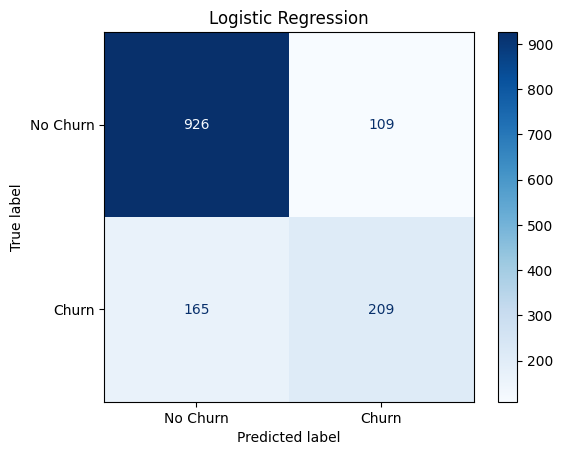

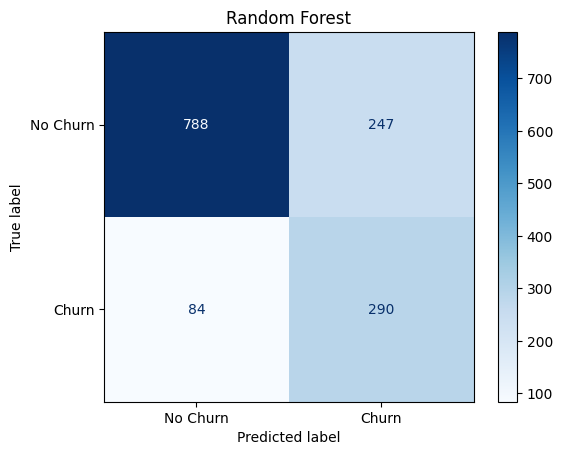

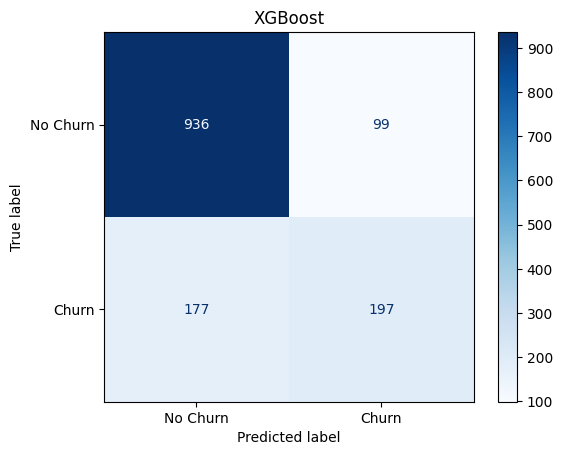

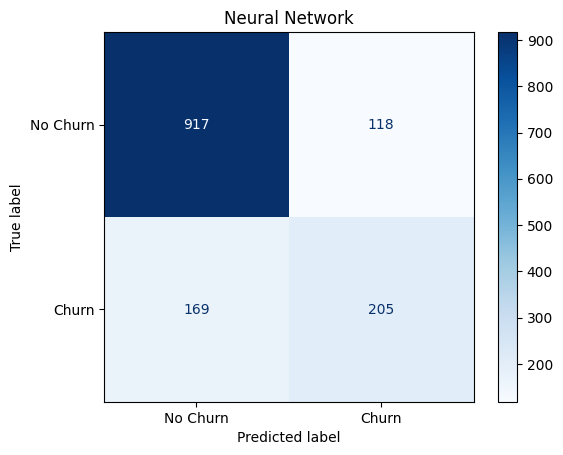

In [166]:
for model_name, metrics in results.items():
    disp = ConfusionMatrixDisplay(confusion_matrix=metrics['confusion_matrix'], display_labels=['No Churn', 'Churn'])
    disp.plot(cmap='Blues')
    disp.ax_.set_title(model_name)
plt.show()

#### Business Impact Analysis

Accuracy treats every mistake as equal, the business doesn't. Missing a churner costs their future revenue; targeting a loyal customer only wastes a retention offer. The precision-recall curves show the trade-off each model offers, and the threshold sweep below picks the operating point that maximises expected net savings instead of accuracy.

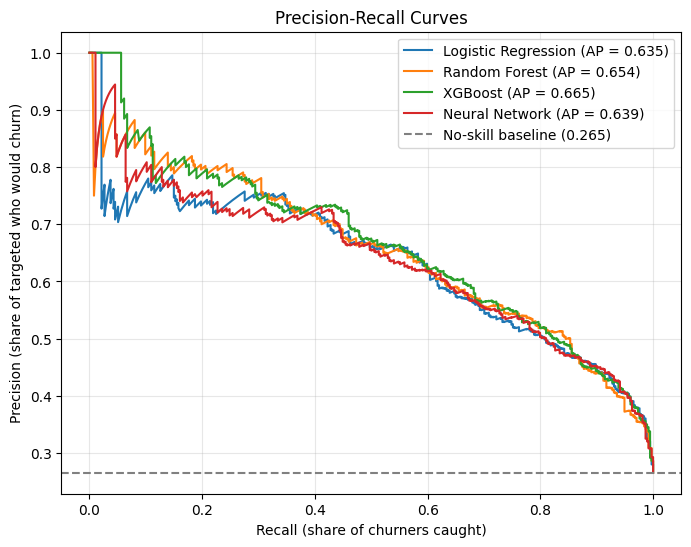

In [167]:
# Precision-Recall curves
probas = {
    'Logistic Regression': lr_y_proba,
    'Random Forest': rf_y_proba,
    'XGBoost': xg_y_proba,
    'Neural Network': nn_y_proba
}

plt.figure(figsize=(8, 6))
for model_name, y_proba in probas.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f'{model_name} (AP = {ap:.3f})')

plt.axhline(y_test.mean(), color='grey', linestyle='--', label=f'No-skill baseline ({y_test.mean():.3f})')
plt.xlabel('Recall (share of churners caught)')
plt.ylabel('Precision (share of targeted who would churn)')
plt.title('Precision-Recall Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

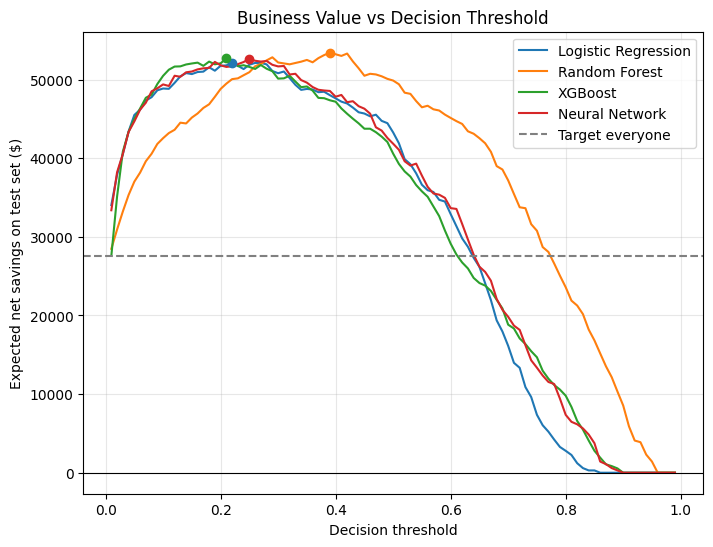

In [168]:
INTERVENTION_COST = 50.0
RETENTION_SUCCESS_RATE = 0.30
RETENTION_MONTHS = 12

monthly_charges = X_test['MonthlyCharges'].to_numpy()
y_true = y_test.to_numpy()

value_if_targeted = np.where(
    y_true == 1,
    RETENTION_SUCCESS_RATE * RETENTION_MONTHS * monthly_charges,
    0.0
) - INTERVENTION_COST

def expected_savings(y_proba, threshold):
    return value_if_targeted[y_proba >= threshold].sum()

thresholds = np.arange(0.01, 1.00, 0.01)

plt.figure(figsize=(8, 6))
business_results = {}
for model_name, y_proba in probas.items():
    savings = np.array([expected_savings(y_proba, t) for t in thresholds])
    best_idx = savings.argmax()
    business_results[model_name] = {
        'best_threshold': thresholds[best_idx],
        'best_savings': savings[best_idx],
        'savings_at_default': expected_savings(y_proba, 0.5),
    }
    line, = plt.plot(thresholds, savings, label=model_name)
    plt.scatter(thresholds[best_idx], savings[best_idx], color=line.get_color(), zorder=3)

plt.axhline(value_if_targeted.sum(), color='grey', linestyle='--', label='Target everyone')
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Decision threshold')
plt.ylabel('Expected net savings on test set ($)')
plt.title('Business Value vs Decision Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [169]:
print(f"Target everyone:  ${value_if_targeted.sum():>10,.0f}")
print(f"Target no one:    ${0:>10,.0f}\n")

print(f"{'Model':<22}{'Best threshold':>16}{'Savings @ best':>16}{'Savings @ 0.5':>16}")
print("-" * 70)
for model_name, res in business_results.items():
    print(f"{model_name:<22}{res['best_threshold']:>16.2f}"
          f"{res['best_savings']:>16,.0f}{res['savings_at_default']:>16,.0f}")

Target everyone:  $    27,524
Target no one:    $         0

Model                   Best threshold  Savings @ best   Savings @ 0.5
----------------------------------------------------------------------
Logistic Regression               0.22          52,159          43,271
Random Forest                     0.39          53,408          49,869
XGBoost                           0.21          52,678          40,575
Neural Network                    0.25          52,634          41,837


The model with the best business value is the **Random Forest**. It has the highest churn recall.